In [1]:
# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input, Bidirectional,
    GaussianNoise
)
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ------------------------------------------
# Rutas
# ------------------------------------------
DATA_PATH = "/content/drive/MyDrive/Curso Especializacion/Proyecto/master_dataset_colab.csv"
RESULTS_DIR = "/content/drive/MyDrive/Curso Especializacion/Proyecto/results"
DAY6_RESULTS = os.path.join(RESULTS_DIR, "day6_hyperparams_results.csv")
DAY7_RESULTS = os.path.join(RESULTS_DIR, "day7_architecture_results.csv")
os.makedirs(RESULTS_DIR, exist_ok=True)

RESULTS_CSV = os.path.join(RESULTS_DIR, "day8_advanced_results.csv")
CV_RESULTS_CSV = os.path.join(RESULTS_DIR, "day8_cv_results.csv")
ENSEMBLE_DIR = os.path.join(RESULTS_DIR, "ensemble_models")
os.makedirs(ENSEMBLE_DIR, exist_ok=True)

In [4]:
# ==========================================
# 2. CARGAR CONFIGURACIÓN ÓPTIMA
# ==========================================
print("\n📋 Cargando resultados previos...")

# Mejor hiperparámetros (Día 6)
if os.path.exists(DAY6_RESULTS):
    day6_df = pd.read_csv(DAY6_RESULTS)
    best6 = day6_df.dropna(subset=['test_mae_real']).nsmallest(1, 'test_mae_real').iloc[0]
    BEST_LR = best6['learning_rate']
    BEST_BATCH = int(best6['batch_size'])
    BEST_OPTIMIZER = best6['optimizer']
    BEST_DROPOUT = best6['dropout']
    BEST_SEQ = int(best6['seq_length'])
    print(f"  Día 6 → lr={BEST_LR}, batch={BEST_BATCH}, opt={BEST_OPTIMIZER}, "
          f"dropout={BEST_DROPOUT}, seq={BEST_SEQ}")
else:
    BEST_LR = 0.001; BEST_BATCH = 64; BEST_OPTIMIZER = 'adam'
    BEST_DROPOUT = 0.2; BEST_SEQ = 24

# Mejor arquitectura (Día 7)
BEST_ARCH = 'LSTM_3Layer'  # Default
if os.path.exists(DAY7_RESULTS):
    day7_df = pd.read_csv(DAY7_RESULTS)
    best7 = day7_df.nsmallest(1, 'test_mae_real').iloc[0]
    BEST_ARCH = best7['architecture']
    print(f"  Día 7 → Arquitectura ganadora: {BEST_ARCH}, MAE={best7['test_mae_real']:.4f}")


📋 Cargando resultados previos...
  Día 6 → lr=0.001, batch=64, opt=rmsprop, dropout=0.2, seq=24
  Día 7 → Arquitectura ganadora: LSTM_Attention, MAE=2.6375


In [5]:
# ==========================================
# 3. CARGA Y PREPARACIÓN DE DATOS
# ==========================================
print("\n📂 Cargando datos...")
df = pd.read_csv(DATA_PATH)
print(f"  Shape: {df.shape}")

# Asegurar encodings cíclicos
if 'hour_sin' not in df.columns:
    if 'hour' in df.columns:
        df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    if 'day_of_week' in df.columns:
        df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
        df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    print(f"  Shape con features cíclicos: {df.shape}")


📂 Cargando datos...
  Shape: (195183, 22)
  Shape con features cíclicos: (195183, 22)


In [6]:
df['fecha'] = pd.to_datetime(df['fecha'])
# Eliminar la columna 'fecha' antes de pasar al modelo, ya que ya tenemos características de tiempo numéricas
df = df.drop(columns=['fecha'])
print(f"Columnas después de eliminar 'fecha': {list(df.columns)}")
print(f"Tipos de datos actualizados:\n{df.dtypes}")

Columnas después de eliminar 'fecha': ['pm25', 'no2', 'o3', 'temperatura', 'velocidad_viento', 'precipitacion', 'humedad_relativa', 'hora_del_dia', 'dia_de_la_semana', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_rolling_6h', 'station_name', 'station_Francia', 'station_Molí del Sol', 'station_Pista de Silla', 'station_Puerto Moll Trans. Ponent', 'station_Puerto Valencia', 'station_Puerto llit antic Túria', 'station_Universidad Politécnica']
Tipos de datos actualizados:
pm25                                 float64
no2                                  float64
o3                                   float64
temperatura                          float64
velocidad_viento                     float64
precipitacion                        float64
humedad_relativa                     float64
hora_del_dia                           int64
dia_de_la_semana                       int64
pm25_lag1                            float64
pm25_lag2                            float64
pm25_lag3                      

In [7]:
# ==========================================
# 4. FUNCIONES AUXILIARES
# ==========================================
def create_sequences_by_station(data, seq_length, target_col_name='pm25', group_col='station_name'):
    """Genera secuencias temporales agrupadas por estación."""
    xs, ys = [], []
    for station, group in data.groupby(group_col):
        group_no_station = group.drop(columns=[group_col])
        group_values = group_no_station.values
        target_values = group[target_col_name].values
        for i in range(len(group_values) - seq_length):
            xs.append(group_values[i:(i + seq_length), :])
            ys.append(target_values[i + seq_length])
    return np.array(xs), np.array(ys)


def prepare_data(df, seq_length, seed=42):
    """Normaliza, crea secuencias y divide en train/val/test."""
    scaler = MinMaxScaler()
    cols_to_scale = [c for c in df.columns if c != 'station_name']
    df_scaled = df.copy()
    df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
    pm25_col_idx = cols_to_scale.index('pm25')
    n_features = len(cols_to_scale)

    X, y = create_sequences_by_station(df_scaled, seq_length)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=seed)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=seed)

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'scaler': scaler, 'pm25_col_idx': pm25_col_idx,
        'n_features': n_features, 'n_input_features': X.shape[2],
        'X_all': X, 'y_all': y,
    }


def inverse_pm25(values, scaler, pm25_col_idx, n_features):
    """Desnormaliza valores de PM2.5."""
    dummy = np.zeros((len(values), n_features))
    dummy[:, pm25_col_idx] = values.flatten()
    dummy_inv = scaler.inverse_transform(dummy)
    return dummy_inv[:, pm25_col_idx]

In [8]:
from tensorflow.keras.layers import Softmax, Multiply, Lambda, Input, LSTM, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, RMSprop
import tensorflow as tf

In [9]:
# ==========================================
# 5. MODELO AVANZADO CON REGULARIZACIÓN
# ==========================================
def build_advanced_model(
    arch_name, seq_length, n_features,
    dropout=0.2, lr=0.001, opt='adam',
    l2_reg=1e-4, use_noise=True
):
    """
    Construye el modelo con las mejoras avanzadas:
    - Regularización L2 en kernels LSTM
    - GaussianNoise en inputs
    """
    optimizer = Adam(learning_rate=lr) if opt == 'adam' else RMSprop(learning_rate=lr)

    if arch_name == 'LSTM_2Layer':
        model = Sequential([
            Input(shape=(seq_length, n_features)),
            GaussianNoise(0.01) if use_noise else Dropout(0.0),
            LSTM(128, activation='relu', return_sequences=True,
                 kernel_regularizer=l2(l2_reg)),
            Dropout(dropout),
            LSTM(64, activation='relu', kernel_regularizer=l2(l2_reg)),
            Dropout(dropout),
            Dense(16, activation='relu'),
            Dense(1)
        ])

    elif arch_name == 'BiLSTM':
        model = Sequential([
            Input(shape=(seq_length, n_features)),
            GaussianNoise(0.01) if use_noise else Dropout(0.0),
            Bidirectional(LSTM(64, activation='relu', return_sequences=True,
                              kernel_regularizer=l2(l2_reg))),
            Dropout(dropout),
            Bidirectional(LSTM(32, activation='relu', kernel_regularizer=l2(l2_reg))),
            Dropout(dropout),
            Dense(16, activation='relu'),
            Dense(1)
        ])

    elif arch_name == 'LSTM_Attention':
        inputs = Input(shape=(seq_length, n_features))
        x = GaussianNoise(0.01)(inputs) if use_noise else inputs
        x = LSTM(128, activation='relu', return_sequences=True,
                 kernel_regularizer=l2(l2_reg))(x)
        x = Dropout(dropout)(x)
        x = LSTM(64, activation='relu', return_sequences=True,
                 kernel_regularizer=l2(l2_reg))(x)
        x = Dropout(dropout)(x)

        attention_scores = Dense(1, activation='tanh')(x)

        attention_weights = Softmax(axis=1)(attention_scores)

        weighted_sequence = Multiply()([x, attention_weights])

        context = Lambda(lambda z: tf.reduce_sum(z, axis=1))(weighted_sequence)
        out = Dense(16, activation='relu')(context)
        out = Dropout(max(dropout - 0.1, 0.1))(out)
        output = Dense(1)(out)
        model = Model(inputs=inputs, outputs=output)

    else:  # LSTM_3Layer (default)
        model = Sequential([
            Input(shape=(seq_length, n_features)),
            GaussianNoise(0.01) if use_noise else Dropout(0.0),
            LSTM(128, activation='relu', return_sequences=True,
                 kernel_regularizer=l2(l2_reg)),
            Dropout(dropout),
            LSTM(64, activation='relu', return_sequences=True,
                 kernel_regularizer=l2(l2_reg)),
            Dropout(dropout),
            LSTM(32, activation='relu', kernel_regularizer=l2(l2_reg)),
            Dropout(max(dropout - 0.1, 0.1)),
            Dense(16, activation='relu'),
            Dense(1)
        ])

    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model


def train_model_advanced(model, data, batch_size, epochs=80, patience=5, verbose=0):
    """
    Entrena con callbacks avanzados:
    - EarlyStopping en val_mae (no val_loss) con patience 5
    - ReduceLROnPlateau con cooldown 2
    """
    early_stop = EarlyStopping(
        monitor='val_mae',
        patience=patience,
        restore_best_weights=True,
        verbose=0,
        mode='min'
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_mae',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        cooldown=2,
        verbose=0,
        mode='min'
    )

    start_time = time.time()
    history = model.fit(
        data['X_train'], data['y_train'],
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(data['X_val'], data['y_val']),
        callbacks=[early_stop, reduce_lr],
        verbose=verbose
    )
    training_time = time.time() - start_time

    return history, training_time

In [10]:
# ==========================================
# 6. ENTRENAMIENTO CON REGULARIZACIÓN
# ==========================================
print(f"\n📂 Preparando datos con seq_length={BEST_SEQ}...")
data = prepare_data(df, BEST_SEQ, seed=SEED)
print(f"  Train: {data['X_train'].shape} | Val: {data['X_val'].shape} | Test: {data['X_test'].shape}")

print(f"\n{'='*60}")
print(f"🔄 Entrenando modelo avanzado: {BEST_ARCH} + L2 + GaussianNoise")
print(f"{'='*60}")

model_adv = build_advanced_model(
    BEST_ARCH, BEST_SEQ, data['n_input_features'],
    dropout=BEST_DROPOUT, lr=BEST_LR, opt=BEST_OPTIMIZER,
    l2_reg=1e-4, use_noise=True
)
model_adv.summary()

history_adv, time_adv = train_model_advanced(
    model_adv, data, BEST_BATCH, epochs=80, patience=5
)

# Evaluar
y_pred_adv = model_adv.predict(data['X_test'])
y_test_real = inverse_pm25(data['y_test'], data['scaler'], data['pm25_col_idx'], data['n_features'])
y_pred_adv_real = inverse_pm25(y_pred_adv, data['scaler'], data['pm25_col_idx'], data['n_features'])

mae_adv = mean_absolute_error(y_test_real, y_pred_adv_real)
rmse_adv = np.sqrt(mean_squared_error(y_test_real, y_pred_adv_real))
r2_adv = r2_score(y_test_real, y_pred_adv_real)

print(f"\n  📊 Modelo Avanzado:")
print(f"     MAE:  {mae_adv:.4f} µg/m³")
print(f"     RMSE: {rmse_adv:.4f} µg/m³")
print(f"     R²:   {r2_adv:.4f}")


📂 Preparando datos con seq_length=24...
  Train: (136510, 24, 20) | Val: (29252, 24, 20) | Test: (29253, 24, 20)

🔄 Entrenando modelo avanzado: LSTM_Attention + L2 + GaussianNoise


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 24, 20)    │          0 │ input_layer[0][0] │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 128)   │     76,288 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 24, 64)    │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 24, 1)     │         65 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 24, 1)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 24, 64)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │      1,040 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         17 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 126,818 (495.38 KB)

 Trainable params: 126,818 (495.38 KB)

 Non-trainable params: 0 (0.00 B)

915/915 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

  📊 Modelo Avanzado:
     MAE:  2.7128 µg/m³
     RMSE: 4.8097 µg/m³
     R²:   0.7557


In [11]:
# ==========================================
# 7. ENSEMBLE DE 3 MODELOS
# ==========================================
print(f"\n{'='*60}")
print("🔄 Entrenando Ensemble (3 modelos con distintas seeds)")
print(f"{'='*60}")

ensemble_seeds = [42, 123, 456]
ensemble_predictions = []
ensemble_results = []

for idx, seed_val in enumerate(ensemble_seeds):
    print(f"\n  --- Modelo {idx+1}/3 (seed={seed_val}) ---")
    np.random.seed(seed_val)
    tf.random.set_seed(seed_val)

    model_ens = build_advanced_model(
        BEST_ARCH, BEST_SEQ, data['n_input_features'],
        dropout=BEST_DROPOUT, lr=BEST_LR, opt=BEST_OPTIMIZER,
        l2_reg=1e-4, use_noise=True
    )

    history_ens, time_ens = train_model_advanced(
        model_ens, data, BEST_BATCH, epochs=80, patience=5, verbose=0
    )

    # Guardar modelo individual
    model_path = os.path.join(ENSEMBLE_DIR, f"model_seed{seed_val}.keras")
    model_ens.save(model_path)

    # Predecir
    y_pred_ens = model_ens.predict(data['X_test'])
    y_pred_ens_real = inverse_pm25(y_pred_ens, data['scaler'], data['pm25_col_idx'], data['n_features'])
    ensemble_predictions.append(y_pred_ens_real)

    mae_ens = mean_absolute_error(y_test_real, y_pred_ens_real)
    print(f"  MAE individual: {mae_ens:.4f} µg/m³")

    ensemble_results.append({
        'seed': seed_val,
        'mae_real': round(mae_ens, 4),
        'rmse_real': round(np.sqrt(mean_squared_error(y_test_real, y_pred_ens_real)), 4),
        'r2_real': round(r2_score(y_test_real, y_pred_ens_real), 4),
    })

    tf.keras.backend.clear_session()

# Predicción promediada del ensemble
y_ensemble = np.mean(ensemble_predictions, axis=0)
mae_ensemble = mean_absolute_error(y_test_real, y_ensemble)
rmse_ensemble = np.sqrt(mean_squared_error(y_test_real, y_ensemble))
r2_ensemble = r2_score(y_test_real, y_ensemble)

print(f"\n  📊 Ensemble (promedio 3 modelos):")
print(f"     MAE:  {mae_ensemble:.4f} µg/m³")
print(f"     RMSE: {rmse_ensemble:.4f} µg/m³")
print(f"     R²:   {r2_ensemble:.4f}")


🔄 Entrenando Ensemble (3 modelos con distintas seeds)

  --- Modelo 1/3 (seed=42) ---
Epoch 1/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step - loss: 0.0182 - mae: 0.0701 - val_loss: 0.0111 - val_mae: 0.0624 - learning_rate: 0.0010
Epoch 2/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0098 - mae: 0.0624 - val_loss: 0.0077 - val_mae: 0.0524 - learning_rate: 0.0010
Epoch 3/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0080 - mae: 0.0558 - val_loss: 0.0064 - val_mae: 0.0452 - learning_rate: 0.0010
Epoch 4/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.0070 - mae: 0.0511 - val_loss: 0.0062 - val_mae: 0.0460 - learning_rate: 0.0010
Epoch 5/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - loss: 0.0066 - mae: 0.0489 - val_loss: 0.0063 - val_mae: 0.0471 - learning_rate: 0.0010
Epoch 6/80
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 0.0060 - mae: 0.0457 - val_loss: 0.0051 - val_mae: 0.0393 - learning_rate: 5.0000e-04
Epoch 7/80
2133/2133 ━━━━━━━━━━━━━━━━━

In [12]:
# ==========================================
# 8. CROSS-VALIDATION TEMPORAL
# ==========================================
print(f"\n{'='*60}")
print("🔄 Cross-Validation Temporal (5-fold)")
print(f"{'='*60}")

# Preparar datos sin shuffle para split temporal
scaler_cv = MinMaxScaler()
cols_to_scale = [c for c in df.columns if c != 'station_name']
df_cv = df.copy()
df_cv[cols_to_scale] = scaler_cv.fit_transform(df[cols_to_scale])
pm25_idx_cv = cols_to_scale.index('pm25')
n_feat_cv = len(cols_to_scale)

X_all, y_all = create_sequences_by_station(df_cv, BEST_SEQ)
print(f"  Total secuencias: {X_all.shape[0]}")

tscv = TimeSeriesSplit(n_splits=5)
cv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_all)):
    print(f"\n  --- Fold {fold+1}/5 ---")
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    X_tr, X_va = X_all[train_idx], X_all[val_idx]
    y_tr, y_va = y_all[train_idx], y_all[val_idx]

    print(f"  Train: {X_tr.shape} | Val: {X_va.shape}")

    model_cv = build_advanced_model(
        BEST_ARCH, BEST_SEQ, X_all.shape[2],
        dropout=BEST_DROPOUT, lr=BEST_LR, opt=BEST_OPTIMIZER,
        l2_reg=1e-4, use_noise=True
    )

    early_stop_cv = EarlyStopping(
        monitor='val_mae', patience=5,
        restore_best_weights=True, verbose=0, mode='min'
    )
    reduce_lr_cv = ReduceLROnPlateau(
        monitor='val_mae', factor=0.5, patience=2,
        min_lr=1e-6, cooldown=2, verbose=0, mode='min'
    )

    model_cv.fit(
        X_tr, y_tr,
        epochs=80,
        batch_size=BEST_BATCH,
        validation_data=(X_va, y_va),
        callbacks=[early_stop_cv, reduce_lr_cv],
        verbose=0
    )

    # Evaluar fold
    y_pred_cv = model_cv.predict(X_va)

    y_va_real = inverse_pm25(y_va, scaler_cv, pm25_idx_cv, n_feat_cv)
    y_pred_cv_real = inverse_pm25(y_pred_cv, scaler_cv, pm25_idx_cv, n_feat_cv)

    mae_cv = mean_absolute_error(y_va_real, y_pred_cv_real)
    rmse_cv = np.sqrt(mean_squared_error(y_va_real, y_pred_cv_real))
    r2_cv = r2_score(y_va_real, y_pred_cv_real)

    print(f"  MAE: {mae_cv:.4f} | RMSE: {rmse_cv:.4f} | R²: {r2_cv:.4f}")

    cv_results.append({
        'fold': fold + 1,
        'mae_real': round(mae_cv, 4),
        'rmse_real': round(rmse_cv, 4),
        'r2_real': round(r2_cv, 4),
    })

    tf.keras.backend.clear_session()

cv_df = pd.DataFrame(cv_results)
cv_df.to_csv(CV_RESULTS_CSV, index=False)

print(f"\n  📊 Cross-Validation Resumen:")
print(f"     MAE medio:  {cv_df['mae_real'].mean():.4f} ± {cv_df['mae_real'].std():.4f}")
print(f"     RMSE medio: {cv_df['rmse_real'].mean():.4f} ± {cv_df['rmse_real'].std():.4f}")
print(f"     R² medio:   {cv_df['r2_real'].mean():.4f} ± {cv_df['r2_real'].std():.4f}")


🔄 Cross-Validation Temporal (5-fold)
  Total secuencias: 195015

  --- Fold 1/5 ---
  Train: (32505, 24, 20) | Val: (32502, 24, 20)
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
  MAE: 4.1866 | RMSE: 6.4188 | R²: 0.7028

  --- Fold 2/5 ---
  Train: (65007, 24, 20) | Val: (32502, 24, 20)
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
  MAE: 3.6797 | RMSE: 5.5923 | R²: 0.7162

  --- Fold 3/5 ---
  Train: (97509, 24, 20) | Val: (32502, 24, 20)
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
  MAE: 2.6276 | RMSE: 4.3887 | R²: 0.7506

  --- Fold 4/5 ---
  Train: (130011, 24, 20) | Val: (32502, 24, 20)
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
  MAE: 4.1405 | RMSE: 5.3165 | R²: 0.5506

  --- Fold 5/5 ---
  Train: (162513, 24, 20) | Val: (32502, 24, 20)
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
  MAE: 2.4432 | RMSE: 4.3323 | R²: 0.7502

  📊 Cross-Validation Resumen:
     MAE medio:  3.4155 ± 0.8301
     RMSE medio: 5.2097 ± 0.8752
     R² medio:   0.6941 ± 0.0829



📊 Análisis de Errores


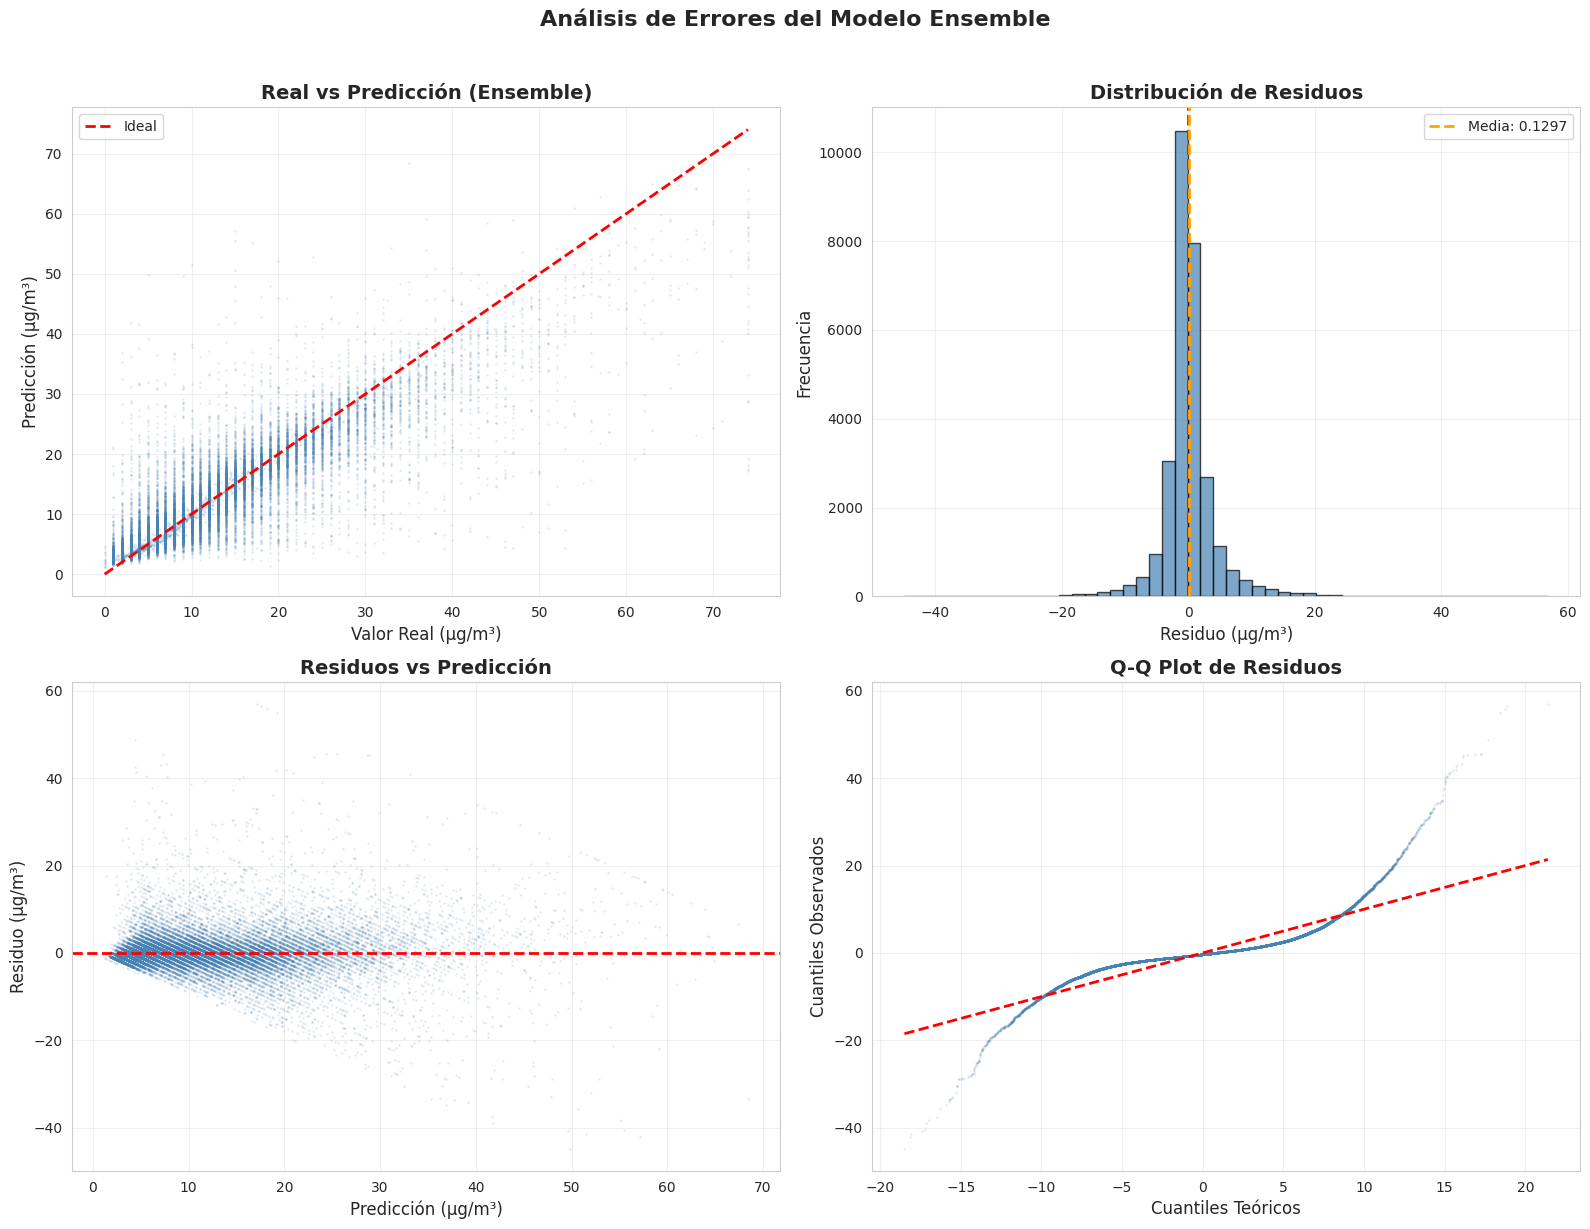

✅ Análisis de errores guardado en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/day8_error_analysis.png


In [13]:
# ==========================================
# 9. ANÁLISIS DE ERRORES
# ==========================================
print(f"\n{'='*60}")
print("📊 Análisis de Errores")
print(f"{'='*60}")

residuals = y_test_real - y_ensemble

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. True vs Predicted
ax = axes[0][0]
ax.scatter(y_test_real, y_ensemble, alpha=0.1, s=1, color='steelblue')
ax.plot([y_test_real.min(), y_test_real.max()],
        [y_test_real.min(), y_test_real.max()],
        'r--', linewidth=2, label='Ideal')
ax.set_xlabel('Valor Real (µg/m³)', fontsize=12)
ax.set_ylabel('Predicción (µg/m³)', fontsize=12)
ax.set_title('Real vs Predicción (Ensemble)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Distribución de residuos
ax = axes[0][1]
ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.axvline(x=residuals.mean(), color='orange', linestyle='--', linewidth=2,
           label=f'Media: {residuals.mean():.4f}')
ax.set_xlabel('Residuo (µg/m³)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución de Residuos', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Residuos vs Valor predicho (homocedasticidad)
ax = axes[1][0]
ax.scatter(y_ensemble, residuals, alpha=0.1, s=1, color='steelblue')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicción (µg/m³)', fontsize=12)
ax.set_ylabel('Residuo (µg/m³)', fontsize=12)
ax.set_title('Residuos vs Predicción', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# 4. Q-Q Plot (normalidad de residuos)
ax = axes[1][1]
sorted_residuals = np.sort(residuals)
n = len(sorted_residuals)
theoretical = np.sort(np.random.normal(residuals.mean(), residuals.std(), n))
ax.scatter(theoretical, sorted_residuals, alpha=0.1, s=1, color='steelblue')
ax.plot([theoretical.min(), theoretical.max()],
        [theoretical.min(), theoretical.max()],
        'r--', linewidth=2)
ax.set_xlabel('Cuantiles Teóricos', fontsize=12)
ax.set_ylabel('Cuantiles Observados', fontsize=12)
ax.set_title('Q-Q Plot de Residuos', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('Análisis de Errores del Modelo Ensemble', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
error_path = os.path.join(RESULTS_DIR, "day8_error_analysis.png")
plt.savefig(error_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Análisis de errores guardado en: {error_path}")

In [14]:
# ==========================================
# 10. RESUMEN FINAL
# ==========================================
print("\n" + "="*60)
print("📋 RESUMEN FINAL — Training & Evaluation")
print("="*60)

summary = {
    'Mejor Hiperparámetros (Día 6)': {
        'lr': BEST_LR, 'batch': BEST_BATCH,
        'optimizer': BEST_OPTIMIZER, 'dropout': BEST_DROPOUT,
        'seq_length': BEST_SEQ
    },
    'Mejor Arquitectura (Día 7)': BEST_ARCH,
    'Modelo Avanzado (L2+Noise)': {
        'MAE': round(mae_adv, 4),
        'RMSE': round(rmse_adv, 4),
        'R2': round(r2_adv, 4),
    },
    'Ensemble (3 modelos)': {
        'MAE': round(mae_ensemble, 4),
        'RMSE': round(rmse_ensemble, 4),
        'R2': round(r2_ensemble, 4),
    },
    'Cross-Validation Temporal (5-fold)': {
        'MAE_mean': round(cv_df['mae_real'].mean(), 4),
        'MAE_std': round(cv_df['mae_real'].std(), 4),
        'R2_mean': round(cv_df['r2_real'].mean(), 4),
    },
    'Residuos': {
        'media': round(residuals.mean(), 4),
        'std': round(residuals.std(), 4),
    }
}

for key, val in summary.items():
    print(f"\n  {key}:")
    if isinstance(val, dict):
        for k, v in val.items():
            print(f"    {k}: {v}")
    else:
        print(f"    {val}")

# Guardar resumen
all_day8_results = {
    'model_advanced': {'mae': mae_adv, 'rmse': rmse_adv, 'r2': r2_adv},
    'ensemble': {'mae': mae_ensemble, 'rmse': rmse_ensemble, 'r2': r2_ensemble},
    'cv_mae_mean': cv_df['mae_real'].mean(),
    'cv_mae_std': cv_df['mae_real'].std(),
    'residual_mean': residuals.mean(),
    'residual_std': residuals.std(),
}
pd.DataFrame([all_day8_results]).to_csv(RESULTS_CSV, index=False)
print(f"\n✅ Resultados guardados en: {RESULTS_CSV}")
print(f"✅ CV Results guardados en: {CV_RESULTS_CSV}")
print(f"✅ Modelos ensemble guardados en: {ENSEMBLE_DIR}/")

print("\n🎯 ¡Entrenamiento avanzado y evaluación completados!")
print("   El ensemble final debería mejorar el MAE respecto al baseline (~3.0 µg/m³)")



📋 RESUMEN FINAL — Training & Evaluation

  Mejor Hiperparámetros (Día 6):
    lr: 0.001
    batch: 64
    optimizer: rmsprop
    dropout: 0.2
    seq_length: 24

  Mejor Arquitectura (Día 7):
    LSTM_Attention

  Modelo Avanzado (L2+Noise):
    MAE: 2.7128
    RMSE: 4.8097
    R2: 0.7557

  Ensemble (3 modelos):
    MAE: 2.6786
    RMSE: 4.7484
    R2: 0.7619

  Cross-Validation Temporal (5-fold):
    MAE_mean: 3.4155
    MAE_std: 0.8301
    R2_mean: 0.6941

  Residuos:
    media: 0.1297
    std: 4.7467

✅ Resultados guardados en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/day8_advanced_results.csv
✅ CV Results guardados en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/day8_cv_results.csv
✅ Modelos ensemble guardados en: /content/drive/MyDrive/Curso Especializacion/Proyecto/results/ensemble_models/

🎯 ¡Entrenamiento avanzado y evaluación completados!
   El ensemble final debería mejorar el MAE respecto al baseline (~3.0 µg/m³)
